In [1]:
from utils import *
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def nice_solver_name(solver: str):
    if "AdditiveSchwarz" in solver:
        return "Additive"
    if "HybridSchwarz" in solver:
        return "Hybrid"
    return solver

In [3]:
# Since the measured times for coarse solver are very noisy, we combine the
# results across different variants with the same coarse solver precision.
def minimize_coarse_solver_times(summary: pd.DataFrame):
    columns = ["coarse solver time", "coarse solver setup time"]
    for col in columns:
        for solver in summary[col].columns.levels[0]:
            precision_variants = summary[col][solver].columns

            for coarse_precision in ["float32", "float64"]:
                variants_to_combine = [
                    variant
                    for variant in precision_variants
                    if variant.split("+")[0] == coarse_precision
                ]
                if len(variants_to_combine) > 1:
                    min_times = summary[col][solver][variants_to_combine].min(axis=1)
                    for variant in variants_to_combine:
                        summary[(col, solver, variant)] = min_times
    return summary

In [4]:
df = pd.read_csv("../results/experiment_parallelism_d2_p1_f11.csv")
df = process_experiments_df(df)

In [5]:
metadata_df = df.apply(extract_row_metadata, axis=1)
metadata_cols = metadata_df.columns.tolist()
df = pd.concat([df, metadata_df], axis=1)
df["solver"] = df["solver"].apply(nice_solver_name)
summary = df.pivot_table(
    index=["coarse m", "solvers m", "fine m"],
    columns="solver",
    values=metadata_cols,
    aggfunc="min",
)
summary.loc[("S8", "S8", "S8")] = np.nan
summary

cg time              coarse solver setup time  \
solver                        Additive       Hybrid                 Additive   
coarse m solvers m fine m                                                      
C10      C10       S11      765.044495   425.208344              2468.531982   
         C11       S11      777.115173   490.114899              2768.566162   
         S10       S11      785.131592   514.082153              2219.208252   
         S11       S11      871.918457   578.884827              2422.424072   
C11      C11       S11     1458.170654   724.193237              6126.093262   
         S11       S11     1559.600342   992.924866              5812.314453   
C8       C10       S11      900.486206   673.965942              1388.386719   
         C11       S11     1036.857056   813.357788              1418.989868   
         S10       S11      948.789856   755.539490              1154.535645   
         S11       S11     1327.575439   993.782837              1521.181763   
         C9        S11     1123.389160          NaN              1343.207520   
         S9        S11      975.915588   708.467346              1147.834839   
C9       C10       S11      685.877930   442.611237              1683.756836   
         C11       S11      746.642700   531.386108              1353.353516   
         S10       S11      696.378540   505.029663              1621.525269   
         S11       S11      905.495667   634.602966              1391.589111   
         C9        S11      881.920715          NaN              1682.563599   
         S9        S11      757.183350   551.021912              1340.123047   
S10      S10       S11      972.484314   648.803284              4109.801758   
         S11       S11     1117.580444   720.774719              3846.281250   
S11      S11       S11     2416.946777  1348.491821             13014.438477   
S8       S10       S11      822.366638   838.339905              1338.237793   
         S11       S11     1301.529785  1125.576538              1490.233154   
         S9        S11      838.517456   767.733643              1366.458252   
S9       S10       S11      699.743469   575.604858              1946.870361   
         S11       S11      864.420227   746.190430              1969.556641   
         S9        S11      735.057556   605.433777              1891.517700   
S8       S8        S8              NaN          NaN                      NaN   

                                        coarse solver time             \
solver                           Hybrid           Additive     Hybrid   
coarse m solvers m fine m                                               
C10      C10       S11      2455.480713           5.095216   5.797747   
         C11       S11      2402.330811           5.094967   5.827942   
         S10       S11      2421.994629           5.094739   5.780630   
         S11       S11      2727.918701           5.101175   5.819081   
C11      C11       S11      6326.326172          18.220576  20.264822   
         S11       S11      6317.721191          18.219847  20.271414   
C8       C10       S11      1409.176025           0.824285   0.964611   
         C11       S11      1377.670898           0.822973   0.971059   
         S10       S11      1342.448608           0.824707   0.964301   
         S11       S11      1130.813721           0.822157   0.970976   
         C9        S11              NaN           0.823824        NaN   
         S9        S11      1379.660645           0.822582   0.963856   
C9       C10       S11      1311.389648           1.762589   2.026957   
         C11       S11      1683.529663           1.758474   2.022570   
         S10       S11      1372.905884           1.759891   2.023821   
         S11       S11      1362.071411           1.760992   2.027795   
         C9        S11              NaN           1.761574        NaN   
         S9        S11      1421.844727           1.758646   2.046720   
S10      S10     

In [6]:
def get_plot_df(coarse_m: int, solver: str):
    data = (
        summary.xs(coarse_m, level="coarse m")
        .xs(solver, level="solver", axis=1)
        .reset_index()
        .set_index("solvers m")
        .copy()
    )
    total_local_solvers = "local solvers"
    total_coarse_solver = "coarse solver"
    total_preconditioner_rest = "other preconditioner components"
    total_not_preconditioner = "outer PCG"
    data[total_local_solvers] = data["local solvers time"] * data["iterations"]
    data[total_coarse_solver] = data["coarse solver time"] * data["iterations"]
    data[total_preconditioner_rest] = (
        data["preconditioner time"]
        - data["local solvers time"]
        - data["coarse solver time"]
    ) * data["iterations"]
    data[total_not_preconditioner] = (
        data["cg time"]
        - data[total_preconditioner_rest]
        - data[total_coarse_solver]
        - data[total_local_solvers]
    )
    to_plot = (
        data[
            [
                total_not_preconditioner,
                total_preconditioner_rest,
                total_coarse_solver,
                total_local_solvers,
            ]
        ]
        / 1000
    )
    to_plot.sort_index(inplace=True, key=lambda x: x.map(mesh_to_key))
    to_plot.rename(index=lambda s: f"${format_mesh(s)}$", inplace=True)
    return to_plot

In [7]:
coarse_meshes = summary.index.get_level_values("coarse m").unique().to_list()
coarse_meshes.sort(key=mesh_to_key)
coarse_meshes

['C8', 'S8', 'C9', 'S9', 'C10', 'S10', 'C11', 'S11']

In [8]:
solvers = summary.columns.get_level_values("solver").unique().tolist()
solvers

['Additive', 'Hybrid']

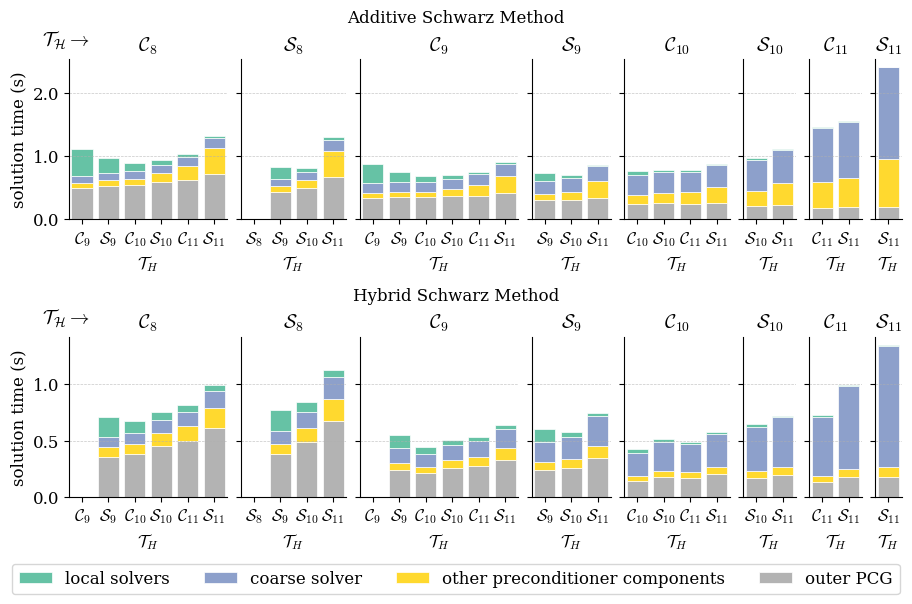

In [9]:
width_ratios = [
    len(summary.xs(cm, level="coarse m").index.get_level_values("solvers m").unique())
    for cm in coarse_meshes
]
fig = plt.figure(figsize=(9, 5.5), layout="constrained")
subfigs = fig.subfigures(nrows=len(solvers), ncols=1)

for i, solver in enumerate(solvers):
    subfig = subfigs[i]
    axes = subfig.subplots(
        nrows=1, ncols=len(coarse_meshes), sharey=True, width_ratios=width_ratios
    )
    for j, coarse_m in enumerate(coarse_meshes):
        ax = axes[j]
        plot_clustered_stacked(
            ax,
            [get_plot_df(coarse_m, solver)],
            [solver],
            add_legend=False,
        )
        ax.set_title(f"${format_mesh(coarse_m)}$")
        ax.set_xlabel("$\\mathcal{{T}}_H$")
        if coarse_m == "C8":
            ax.set_ylabel("solution time (s)")
        if i == 0 and j == 0:
            ax.set_yticks([0, 1, 2])
            ax.set_yticklabels(["0.0", "1.0", "2.0"])

    subfig.suptitle(f"{solver} Schwarz Method", fontsize=12)
    subfig.text(0.04, 0.85, "$\\mathcal{T}_\\mathcal{H}\\rightarrow$", fontsize=14)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles[::-1],
    labels[::-1],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.0),
    ncols=4,
)

fig.savefig("../docs/images/parallelism_plots.svg", bbox_inches="tight")